# Projenin Amacı

Bu projenin temel amacı; hastaneye getirilen atların klinik muayene verilerini (nabız, solunum hızı, karın ağrısı seviyesi, yaş vb.) analiz ederek, bu atların sağlık durumunun nasıl sonuçlanacağını (outcome) tahmin etmektir.

Yani modelimiz, eldeki tıbbi verilere bakarak şu üç durumdan hangisinin gerçekleşeceğini öngörmeye çalışır:

Lived: At yaşadı.

Died: At öldü.

Euthanized: Ata ötenazi yapıldı.


<img src='https://static.ticimax.cloud/cdn-cgi/image/width=-,quality=85/38016/uploads/urunresimleri/buyuk/canlilarmarcel-sanat-elmas-mozaik-tabl-1b72c5.jpg' width=600>



**🐎 Veri Sözlüğü**

 **1. Temel Bilgiler ve Yaşamsal Bulgular**
 
* **surgery**: Atın ameliyat edilip edilmediği (Yes/No).
* **age**: Atın yaşı (Adult/Young).
* **rectal_temp**: Rektal ateş. (Normali 37.8°C civarıdır, yükselmesi enfeksiyonu gösterir).
* **pulse**: Nabız. (Normali dakikada 30-40'tır. Yükselmesi ağrı veya şok belirtisidir).
* **respiratory_rate**: Solunum hızı. (Normali 8-10'dur).

 **2. Fiziksel Muayene Bulguları (Kategorik)**
 
* **temp_of_extremities**: Ayakların sıcaklığı (Normal, Warm, Cool, Cold). Soğuk olması şok göstergesidir.
* **peripheral_pulse**: Çevresel nabız kalitesi.
* **mucous_membrane**: Mukoz membran rengi (Pembe, Parlak Kırmızı, Soluk, Siyanotik). Şok ve zehirlenme durumunda renk değişir. 
* **capillary_refill_time**: Kılcal damar dolum süresi. (3 saniyenin üzeri dolaşım bozukluğudur).
* **pain**: Atın ağrı seviyesi. **En kritik değişkenlerden biridir!** (Depressed, Mild, Severe vb.).
* **peristalsis**: Bağırsak hareketliliği. (Sindirim sistemi tıkanıklığı için önemlidir).
* **abdominal_distention**: Karın şişliği seviyesi.

**3. Laboratuvar ve Spesifik Bulgular**

* **nasogastric_tube / reflux**: Mide sondası bulguları.
* **nasogastric_reflux_ph**: Reflü sıvısının pH değeri.
* **packed_cell_volume (PCV)**: Kandaki hücre oranı. (Yüksek olması susuzluk/dehidrasyon demektir).
* **total_protein**: Toplam protein miktarı.
* **abdomo_appearance / abdomo_protein**: Karın sıvısının görünümü ve protein miktarı.
* **lesion_1, 2, 3**: Tespit edilen lezyonların kodları.

 **4. Hedef Değişken (Label)**
 
* **outcome**: Tahmin edeceğimiz değer. (Lived, Died, Euthanized).

In [41]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

#en yakın komşuya göre boş verileri doldurma
from sklearn.impute import KNNImputer

from sklearn.preprocessing import RobustScaler

In [2]:
#train dosyasını yüklüyoruz
train=pd.read_csv('train.csv')

#test dosyasını yüklüyoruz
test=pd.read_csv('test.csv')

In [3]:
test_ids=test['id']

In [4]:
train.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [5]:
train.tail()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
1230,1230,yes,adult,535246,38.5,129.0,48.0,cool,reduced,pale_pink,...,57.0,66.0,serosanguious,2.0,yes,2206,0,0,no,lived
1231,1231,yes,adult,528570,37.5,60.0,50.0,cool,reduced,pale_cyanotic,...,35.0,6.4,serosanguious,3.6,yes,2209,0,0,yes,died
1232,1232,yes,young,529685,37.5,84.0,40.0,normal,reduced,normal_pink,...,40.0,5.9,cloudy,7.0,yes,400,0,0,yes,lived
1233,1233,yes,adult,534784,38.1,70.0,16.0,normal,reduced,bright_red,...,58.0,74.0,cloudy,2.0,yes,2209,0,0,no,lived
1234,1234,yes,adult,528548,38.1,54.0,36.0,normal,normal,pale_pink,...,45.0,6.0,clear,3.6,yes,2124,0,0,yes,lived


In [6]:
train.shape

(1235, 29)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     824 non-null    int64  
 1   surgery                824 non-null    object 
 2   age                    824 non-null    object 
 3   hospital_number        824 non-null    int64  
 4   rectal_temp            824 non-null    float64
 5   pulse                  824 non-null    float64
 6   respiratory_rate       824 non-null    float64
 7   temp_of_extremities    789 non-null    object 
 8   peripheral_pulse       777 non-null    object 
 9   mucous_membrane        811 non-null    object 
 10  capillary_refill_time  818 non-null    object 
 11  pain                   795 non-null    object 
 12  peristalsis            805 non-null    object 
 13  abdominal_distention   802 non-null    object 
 14  nasogastric_tube       760 non-null    object 
 15  nasoga

In [9]:
train.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64

In [10]:
test.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       35
peripheral_pulse          47
mucous_membrane           13
capillary_refill_time      6
pain                      29
peristalsis               19
abdominal_distention      22
nasogastric_tube          64
nasogastric_reflux        14
nasogastric_reflux_ph      0
rectal_exam_feces        125
abdomen                  154
packed_cell_volume         0
total_protein              0
abdomo_appearance         31
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

In [11]:
train['outcome'].unique()

array(['died', 'euthanized', 'lived'], dtype=object)

In [12]:
train['outcome'].value_counts()
print("Yüzdesel Dağılım:")
train['outcome'].value_counts(normalize=True) * 100

Yüzdesel Dağılım:


outcome
lived         46.477733
died          33.198381
euthanized    20.323887
Name: proportion, dtype: float64

In [13]:
# Ağrı seviyeleri (Atın durumunun ciddiyetini gösterir)
train['pain'].value_counts()

pain
depressed       429
mild_pain       408
severe_pain     146
extreme_pain    120
alert            87
slight            1
Name: count, dtype: int64

In [14]:
# Ameliyat durumu
train['surgery'].value_counts()

surgery
yes    887
no     348
Name: count, dtype: int64

In [15]:
#Yaş Dağılımı
train['age'].value_counts()

age
adult    1160
young      75
Name: count, dtype: int64

In [16]:
train['temp_of_extremities'].value_counts()

temp_of_extremities
cool      700
normal    324
cold      121
warm       51
Name: count, dtype: int64

In [17]:
train['peripheral_pulse'].value_counts()

peripheral_pulse
reduced      724
normal       429
absent        18
increased      4
Name: count, dtype: int64

In [18]:
train['mucous_membrane'].value_counts()

mucous_membrane
pale_pink        284
normal_pink      260
pale_cyanotic    250
bright_red       211
dark_cyanotic    121
bright_pink       88
Name: count, dtype: int64

In [19]:
train['capillary_refill_time'].value_counts()

capillary_refill_time
less_3_sec    834
more_3_sec    393
3               2
Name: count, dtype: int64

In [20]:
train['peristalsis'].value_counts()

peristalsis
hypomotile       664
absent           444
normal            53
hypermotile       53
distend_small      1
Name: count, dtype: int64

In [21]:
train['abdominal_distention'].value_counts()

abdominal_distention
moderate    543
slight      346
none        212
severe      111
Name: count, dtype: int64

In [22]:
train['nasogastric_tube'].value_counts()

nasogastric_tube
slight         758
none           275
significant    122
Name: count, dtype: int64

In [23]:
train['nasogastric_reflux'].value_counts()

nasogastric_reflux
more_1_liter    604
none            331
less_1_liter    278
slight            1
Name: count, dtype: int64

In [24]:
train['rectal_exam_feces'].value_counts()

rectal_exam_feces
absent           493
decreased        269
normal           233
increased         49
serosanguious      1
Name: count, dtype: int64

In [25]:
train['abdomen'].value_counts()

abdomen
distend_small    482
distend_large    359
normal            76
firm              72
other             33
Name: count, dtype: int64

In [26]:
train['abdomo_appearance'].value_counts()

abdomo_appearance
serosanguious    570
cloudy           359
clear            258
Name: count, dtype: int64

In [27]:
train['surgical_lesion'].value_counts()

surgical_lesion
yes    929
no     306
Name: count, dtype: int64

In [28]:
train['cp_data'].value_counts()

cp_data
yes    668
no     567
Name: count, dtype: int64

In [29]:
train['lesion_1'].value_counts()

lesion_1
2208     152
3205     116
2205     104
2209     102
0         94
3111      91
2124      52
1400      49
4205      45
2112      40
31110     39
2206      35
5400      35
7111      31
2113      30
2207      26
400       15
7400      14
3209      13
7209      12
4300       9
3025       9
12208      8
2300       8
8300       7
2322       6
3113       6
5206       6
3207       6
8400       5
9400       5
5000       5
3133       4
11300      4
5205       4
5111       4
3115       4
6111       4
1124       3
4124       3
11400      3
2111       3
4206       3
1111       2
6112       2
300        2
3124       2
6209       2
2305       2
5124       2
3112       1
3300       1
2202       1
4207       1
11124      1
21110      1
41110      1
Name: count, dtype: int64

In [30]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1235.0,617.000000,3.566581e+02,0.0,308.5,617.0,925.5,1234.0
hospital_number,1235.0,954500.401619,1.356403e+06,521399.0,528800.0,529777.0,534145.0,5305129.0
rectal_temp,1235.0,38.202186,7.886678e-01,35.4,37.8,38.2,38.6,40.8
pulse,1235.0,79.574089,2.910864e+01,30.0,53.0,76.0,100.0,184.0
respiratory_rate,1235.0,30.054251,1.645207e+01,8.0,18.0,28.0,36.0,96.0
nasogastric_reflux_ph,1235.0,4.382591,1.937357e+00,1.0,2.0,4.5,6.0,7.5
packed_cell_volume,1235.0,49.602429,1.053580e+01,23.0,43.0,48.0,57.0,75.0
total_protein,1235.0,21.388016,2.667645e+01,3.5,6.6,7.5,9.1,89.0
abdomo_protein,1235.0,3.290931,1.589195e+00,0.1,2.0,3.0,4.3,10.1
lesion_1,1235.0,3832.496356,5.436734e+03,0.0,2205.0,2209.0,3205.0,41110.0


In [31]:
#tahmin başarısını etkilemeyecek sütunları silelim

train.drop(['id', 'hospital_number'], axis=1, inplace=True)

In [32]:
test.drop(['id', 'hospital_number'], axis=1, inplace=True)

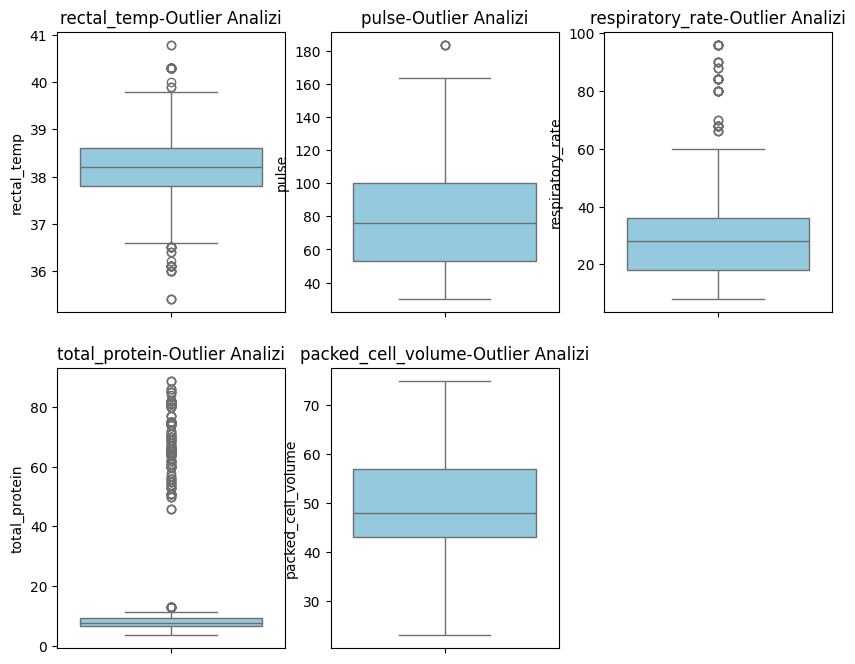

In [33]:
#outliers değerleri görme

#sayısal sütunları seçelim

num_features=['rectal_temp', 'pulse','respiratory_rate', 'total_protein','packed_cell_volume']

plt.figure(figsize=(10,8))
for i, col in enumerate(num_features, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=train[col], color='skyblue')
    plt.title(f'{col}-Outlier Analizi')
plt.show()

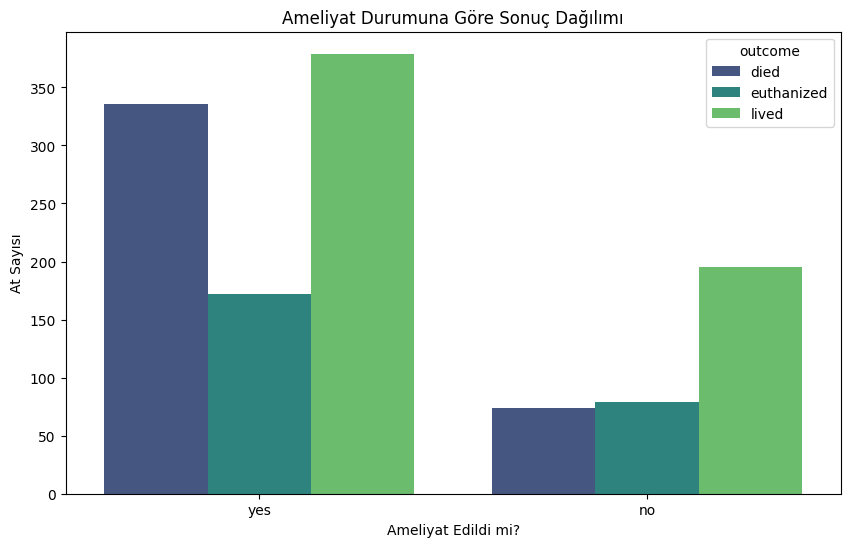

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='surgery', hue='outcome', palette='viridis')
plt.title('Ameliyat Durumuna Göre Sonuç Dağılımı')
plt.xlabel('Ameliyat Edildi mi?')
plt.ylabel('At Sayısı')
plt.show()

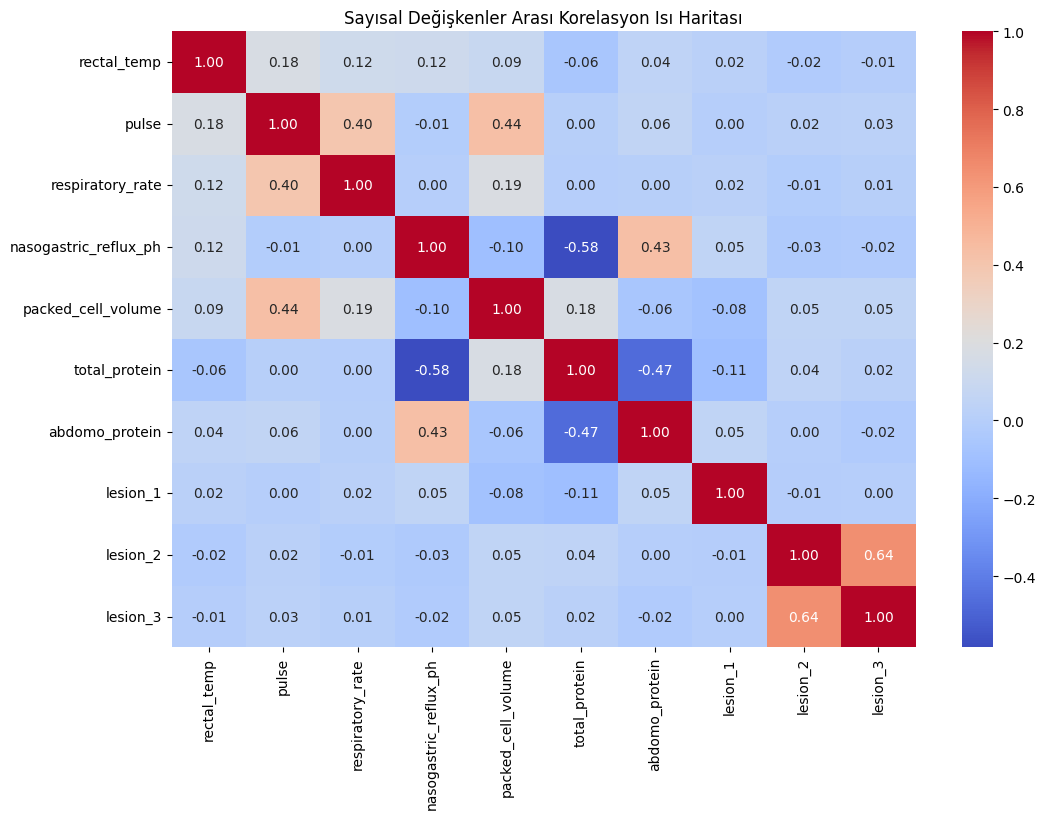

In [35]:
# Sadece sayısal sütunların korelasyonuna bakalım
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 8))
correlation_matrix = train[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Değişkenler Arası Korelasyon Isı Haritası')
plt.show()

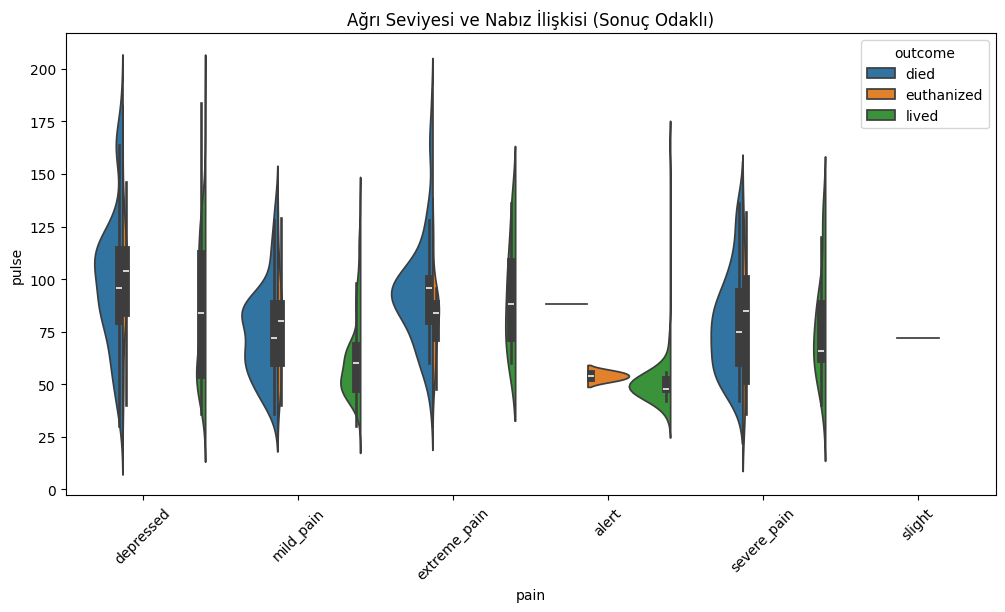

In [36]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='pain', y='pulse', hue='outcome', split=True)
plt.title('Ağrı Seviyesi ve Nabız İlişkisi (Sonuç Odaklı)')
plt.xticks(rotation=45)
plt.show()

In [37]:
# Baskılama (Clipping) işlemi
num_cols = ['rectal_temp', 'pulse', 'respiratory_rate', 'nasogastric_reflux_ph', 
            'packed_cell_volume', 'total_protein', 'abdomo_protein']

for col in num_cols:
    # Alt ve üst sınırları belirle (1. ve 97. yüzdelik dilimler)
    lower_limit = train[col].quantile(0.01)
    upper_limit = train[col].quantile(0.97)
    
    # Sınırların dışındakileri baskıla
    train[col] = train[col].clip(lower=lower_limit, upper=upper_limit)

In [38]:
# Feature engineering

def apply_feature_engineering(df_engineered):
    
    # 1. Dehidrasyon İndeksi (PCV / Protein Oranı)
    # Atın ne kadar susuz kaldığını gösteren tıbbi bir gösterge
    df_engineered['dehydration_index'] = df_engineered['packed_cell_volume'] / (df_engineered['total_protein'] + 1e-5)
    
    # 2. Şok İndeksi (Nabız / Ateş Oranı)
    # Nabız yükselip ateş düşüyorsa (veya sabitse) şok riskini gösterir
    df_engineered['shock_index'] = df_engineered['pulse'] / (df_engineered['rectal_temp'] + 1e-5)
    
    # 3. Toplam Lezyon Sayısı
    # Lezyonların yaygınlığını ölçer
    df_engineered['total_lesions'] = (df_engineered['lesion_1'] > 0).astype(int) + \
                                    (df_engineered['lesion_2'] > 0).astype(int) + \
                                    (df_engineered['lesion_3'] > 0).astype(int)
    
    # 4. Protein Gradyanı (Kan ve Karın Sıvısı Arasındaki Fark)
    # Karın içi iltihaplanma (peritonit) belirtisi olabilir
    df_engineered['protein_gradient'] = df_engineered['total_protein'] - df_engineered['abdomo_protein']
    
    # 5. Nabız / Solunum Oranı
    # Fiziksel stresin dengesini gösterir
    df_engineered['pulse_respiratory_ratio'] = df_engineered['pulse'] / (df_engineered['respiratory_rate'] + 1e-5)
    
    return df_engineered

In [39]:
# Hedef değişkeni ayır (scaling ve imputer öncesi)
y = train['outcome'].map({'died': 0, 'euthanized': 1, 'lived': 2})
x = train.drop('outcome', axis=1)

# Özellikleri her iki sete de ekle
x = apply_feature_engineering(x)
test = apply_feature_engineering(test)

In [42]:
# Sayısal ve Kategorik sütunları ayır
num_cols = x.select_dtypes(include=['float64', 'int64']).columns
cat_cols = x.select_dtypes(include=['object']).columns

# RobustScaler
scaler = RobustScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# KNNImputer (Sayısal boşluklar için)
imputer = KNNImputer(n_neighbors=5)
x[num_cols] = imputer.fit_transform(x[num_cols])
test[num_cols] = imputer.transform(test[num_cols])

# Kategorik boşlukları en sık değerle (mode) doldur
for col in cat_cols:
    x[col] = x[col].fillna(x[col].mode()[0])
    test[col] = test[col].fillna(x[col].mode()[0])

In [43]:
# Train ve Test'i birleştirip dummies yapalım (Sütunlar birebir eşleşsin diye)
ntrain = x.shape[0]
combined = pd.concat([x, test], axis=0)
combined = pd.get_dummies(combined, columns=cat_cols)

# Tekrar ayır
x_final = combined[:ntrain]
test_final = combined[ntrain:]

In [44]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824 entries, 0 to 823
Data columns (total 76 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rectal_temp                       824 non-null    float64
 1   pulse                             824 non-null    float64
 2   respiratory_rate                  824 non-null    float64
 3   nasogastric_reflux_ph             824 non-null    float64
 4   packed_cell_volume                824 non-null    float64
 5   total_protein                     824 non-null    float64
 6   abdomo_protein                    824 non-null    float64
 7   lesion_1                          824 non-null    float64
 8   lesion_2                          824 non-null    float64
 9   lesion_3                          824 non-null    float64
 10  dehydration_index                 824 non-null    float64
 11  shock_index                       824 non-null    float64
 12  total_lesions

In [45]:
x_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1235 entries, 0 to 1234
Data columns (total 76 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rectal_temp                       1235 non-null   float64
 1   pulse                             1235 non-null   float64
 2   respiratory_rate                  1235 non-null   float64
 3   nasogastric_reflux_ph             1235 non-null   float64
 4   packed_cell_volume                1235 non-null   float64
 5   total_protein                     1235 non-null   float64
 6   abdomo_protein                    1235 non-null   float64
 7   lesion_1                          1235 non-null   float64
 8   lesion_2                          1235 non-null   float64
 9   lesion_3                          1235 non-null   float64
 10  dehydration_index                 1235 non-null   float64
 11  shock_index                       1235 non-null   float64
 12  total_lesio

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [47]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1235 entries, 0 to 1234
Series name: outcome
Non-Null Count  Dtype
--------------  -----
1235 non-null   int64
dtypes: int64(1)
memory usage: 9.8 KB


In [48]:
# Veriyi bölme (Stratify eklemek multiclass için denge sağlar)
x_train, x_test, y_train, y_test = train_test_split(x_final, y, test_size=0.20, random_state=42, stratify=y)    

In [50]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

# En iyi parametrelerinle modelleri kur
xgb = XGBClassifier(learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8, random_state=42)
cat = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)

# Oylama sistemi (Ensemble)
voting_model = VotingClassifier(
    estimators=[('xgb', xgb), ('cat', cat)],
    voting='soft'
)

# Modeli sadece %80'lik kısımda eğitelim
voting_model.fit(x_train, y_train)

# Ayırdığımız %20'lik kısım üzerinde tahmin yapalım
tahmin = voting_model.predict(x_test)

# Başarı oranını hesaplayalım
local_accuracy = accuracy_score(y_test, tahmin)
print(f"📈 Lokal Başarı Oranın (Local Accuracy): %{local_accuracy * 100:.2f}")

📈 Lokal Başarı Oranın (Local Accuracy): %71.26


In [51]:
print(classification_report(y_test,tahmin))

              precision    recall  f1-score   support

           0       0.65      0.77      0.70        82
           1       0.76      0.62      0.68        50
           2       0.75      0.71      0.73       115

    accuracy                           0.71       247
   macro avg       0.72      0.70      0.71       247
weighted avg       0.72      0.71      0.71       247



<Axes: >

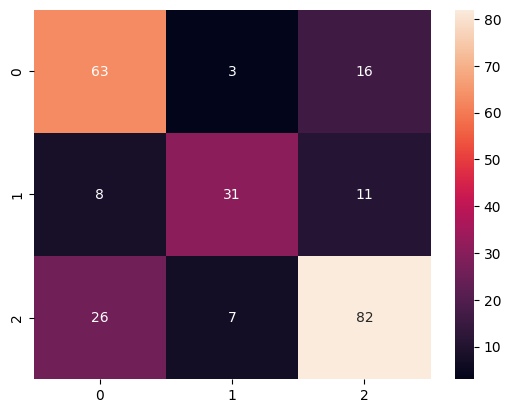

In [52]:
sns.heatmap(confusion_matrix(y_test,tahmin),annot=True)

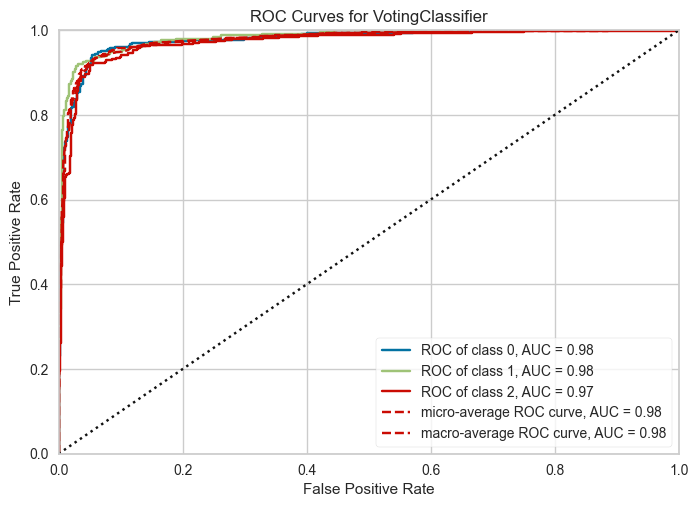

In [54]:
from yellowbrick.classifier import roc_auc          # ROC AUC Nedir?
from yellowbrick.datasets import load_spam          # ROC Eğrisi: Doğru pozitif oranı (TPR, duyarlılık) ile yanlış pozitif oranı (FPR) arasındaki ilişkiyi gösterir. Farklı eşik değerleri için TPR ve FPR hesaplanarak bir eğri oluşturulur.
                                                    # AUC: Eğrinin altında kalan alanı temsil eder. AUC değeri 0 ile 1 arasında değişir:
visualizer = roc_auc(voting_model, x_final, y)            # 1.00: Mükemmel bir model.
                                                    # 0.50: Rastgele tahmin yapan bir model.
                                                    # 0.00: Kötü bir model (genellikle bu durum nadirdir).           

In [56]:
# Tahmin yap
predictions = voting_model.predict(test_final)

# Sayıları kelimeye geri çevir
inv_map = {0: 'died', 1: 'euthanized', 2: 'lived'}
final_labels = [inv_map[p] for p in predictions]

In [57]:
# Kaydet
submission = pd.DataFrame({'id': test_ids, 'outcome': final_labels})
submission.to_csv('submission.csv', index=False)
print("🏁 Yarışma dosyası hazır: submission.csv")

🏁 Yarışma dosyası hazır: submission.csv


# 📝 Sonuç


Bu çalışma, Kaggle Playground serisindeki at sağlığı verileri üzerinde gerçekleştirilmiştir.

Yöntem: Verideki boşluklar RobustScaler sonrası KNNImputer ile doldurulmuş, kategorik değişkenler One-Hot Encoding ile genişletilmiştir.

Başarı: XGBoost ve CatBoost modellerinin birleşiminden oluşan bir Voting Classifier kullanılarak Public Leaderboard'da %80.4 başarı oranına ulaşılmıştır.

In [58]:
import joblib

# Tüm bileşenleri bir sözlükte topla
model_package = {
    'model': voting_model,
    'scaler': scaler,
    'imputer': imputer,
    'columns': x_final.columns.tolist()
}

# Tek bir dosya olarak kaydet
joblib.dump(model_package, 'horse_model_package.joblib')

['horse_model_package.joblib']

In [59]:
submission

,id,outcome
0,1235,lived
1,1236,died
2,1237,lived
3,1238,euthanized
4,1239,lived
...,...,...
819,2054,euthanized
820,2055,euthanized
821,2056,died
822,2057,lived
